In [244]:
import pandas as pd

In [245]:
model_name = "Ridge"
model_name = "CatBoost"

remove_GSE152558 = False

In [246]:
if model_name == "CatBoost":
    results = pd.read_csv("Shap_values/results_validationSet_actualVspredicted_catboost_10.csv", index_col=0)
elif model_name == "Ridge":
    results = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/Ridge/results_validation_untoached_Ridge.csv")


In [247]:
results.head(10)

,Actual,Predicted,Group
0,24.0,23.134676,GSE157585
1,18.0,25.603508,GSE167186
2,23.0,24.474362,GSE167186
3,26.4,39.749360,GSE60590
4,71.0,68.617051,GSE157585
5,26.4,37.057557,GSE60590
6,71.0,69.316779,GSE157585
7,27.5,29.437722,GSE60590
8,31.0,30.305390,GSE164471
9,92.0,75.703634,GSE167186


In [248]:
# remove GSE152558
if remove_GSE152558:
    results = results[results['Group'] != 'GSE152558']

In [249]:
# Check if there is statistical difference between groups
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

results['Difference'] = abs(results['Predicted'] - results['Actual'])
groups = results['Group'].unique()
groups

array(['GSE157585', 'GSE167186', 'GSE60590', 'GSE164471', 'GSE152558',
       'GSE129643'], dtype=object)

In [250]:
## because different group sizes
grouped_data = [results[results['Group'] == group]['Difference'] for group in groups]
stat, p = stats.kruskal(*grouped_data)
print(f"Kruskal-Wallis H-statistic: {stat}, p-value: {p}")
# If p < 0.05, there is a statistically significant difference between groups
if p < 0.05:
    print("There is a statistically significant difference between groups.")
else:
    print("There is no statistically significant difference between groups.")


Kruskal-Wallis H-statistic: 23.598948734912426, p-value: 0.00025922412713079245
There is a statistically significant difference between groups.


In [251]:
# do it with KW test
from itertools import combinations
non_significant_pairs = []
significant_pairs = []
for group1, group2 in combinations(groups, 2):
    if group1 == group2:
        continue

    data1 = results[results['Group'] == group1]['Difference']
    data2 = results[results['Group'] == group2]['Difference']
    stat, p = stats.kruskal(data1, data2)
    if p < 0.05:
        significant_pairs.append((group1, group2))
        print(f"  -> Significant difference between {group1} and {group2}. p-value: {p}")
    else:
        non_significant_pairs.append((group1, group2))

  -> Significant difference between GSE157585 and GSE167186. p-value: 1.0537681406605807e-06
  -> Significant difference between GSE157585 and GSE164471. p-value: 0.027592712018693455
  -> Significant difference between GSE157585 and GSE129643. p-value: 0.04060695963339818
  -> Significant difference between GSE167186 and GSE60590. p-value: 0.016139355616295235


In [252]:

print(f" {len(non_significant_pairs)} non-significant pairs found.")
print(f" {len(significant_pairs)} significant pairs found.")

 11 non-significant pairs found.
 4 significant pairs found.


In [253]:
significant_pairs

[('GSE157585', 'GSE167186'),
 ('GSE157585', 'GSE164471'),
 ('GSE157585', 'GSE129643'),
 ('GSE167186', 'GSE60590')]

In [254]:
# count apparances of each group in significant pairs
from collections import Counter
group_counts = Counter()
for group1, group2 in significant_pairs:
    group_counts[group1] += 1
    group_counts[group2] += 1
group_counts

Counter({'GSE157585': 3,
         'GSE167186': 2,
         'GSE164471': 1,
         'GSE129643': 1,
         'GSE60590': 1})

In [255]:
# Make new tags for the name of the groups adding in the number of samples in each group
group_counts = results['Group'].value_counts()
group_labels = {group: f"{group} (n={count})" for group, count in group_counts.items()}
groups = results['Group'].map(group_labels)
groups

0      GSE157585 (n=29)
1      GSE167186 (n=32)
2      GSE167186 (n=32)
3       GSE60590 (n=16)
4      GSE157585 (n=29)
             ...       
103    GSE157585 (n=29)
104    GSE167186 (n=32)
105    GSE164471 (n=14)
106    GSE157585 (n=29)
107    GSE167186 (n=32)
Name: Group, Length: 108, dtype: object

/tmp/ipykernel_17131/3102735592.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results, x='Group', y='Difference', palette='Dark2')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GSE157585 vs. GSE167186: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.054e-06 Stat=2.383e+01
GSE167186 vs. GSE60590: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.614e-02 Stat=5.788e+00
GSE157585 vs. GSE164471: Kruskal-Wallis independent samples (pairwise between groups), P_val:2.759e-02 Stat=4.853e+00
GSE157585 vs. GSE129643: Kruskal-Wallis independent samples (pairwise between groups), P_val:4.061e-02 Stat=4.192e+00


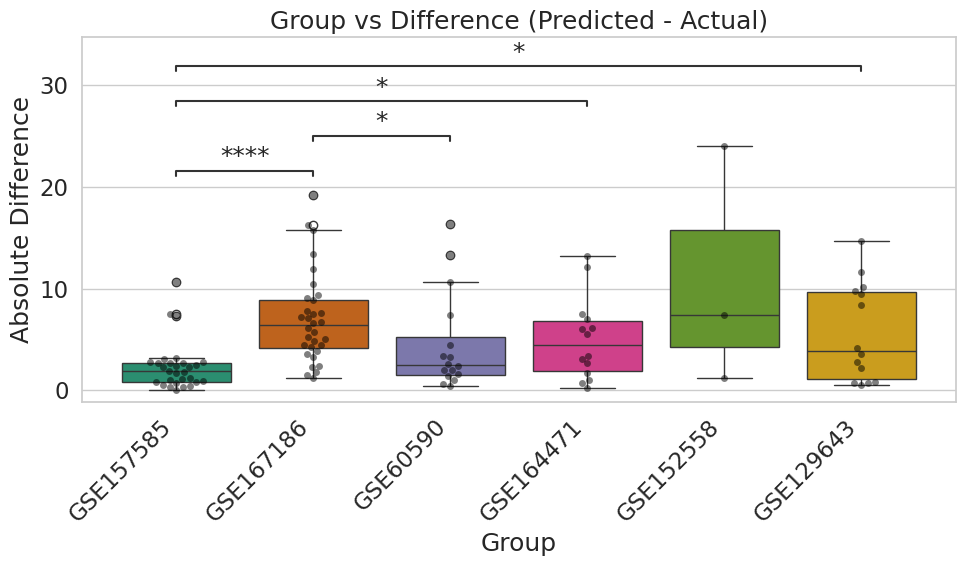

<Figure size 640x480 with 0 Axes>

In [256]:
from statannotations.Annotator import Annotator

# plot a boxplot to visualize the differences mark significance with *
# Make the names to wrap if they are too long
groups = groups.apply(lambda x: '\n'.join(x.split(' ')) if len(x) > 9 else x)
# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=results, x='Group', y='Difference', palette='Dark2')
sns.swarmplot(data=results, x='Group', y='Difference', color='k', alpha=0.5)
plt.title('Group vs Difference (Predicted - Actual)')
plt.ylabel('Absolute Difference')
plt.xlabel('Group')
# Add significance annotations
pairs = significant_pairs
# Update pairs to use the new group labels
annotator = Annotator(plt.gca(), pairs, data=results, x='Group', y='Difference')
annotator.configure(test='Kruskal', text_format='star', loc='inside', verbose=2)
annotator.apply_and_annotate()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig(f"deep_learning/Results/Group_vs_Difference_{model_name}{'_remove_GSE152558' if remove_GSE152558 else ''}.svg", bbox_inches='tight')

# Consider size

In [257]:
training_set = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_inmose_z_score_Train_set.csv", index_col=0)

/tmp/ipykernel_17131/2957559361.py:1: DtypeWarning: Columns (34507) have mixed types. Specify dtype option on import or set low_memory=False.
  training_set = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_inmose_z_score_Train_set.csv", index_col=0)


In [258]:
# keep only column Age, Sample and Experiment
training_set = training_set[['Age', 'Sample', 'Experiment']]
training_set.reset_index(drop=True, inplace=True)
training_set.head()

,Age,Sample,Experiment
0,73.0,SRR13759000,GSE167186
1,71.0,SRR12604113,GSE157585
2,63.0,SRR13388773,GSE164471
3,69.0,SRR13758999,GSE167186
4,64.0,SRR13759067,GSE167186


In [266]:
len(training_set)

162

In [259]:
# count number of samples in each group
train_group_counts = training_set['Experiment'].value_counts()
train_group_counts

Experiment
GSE167186    53
GSE157585    45
GSE164471    29
GSE129643    17
GSE60590     16
GSE152558     2
Name: count, dtype: int64

In [260]:
# merge number of samples in each group to results
results['Train_Group_Count'] = results['Group'].map(train_group_counts)
results.head()

,Actual,Predicted,Group,Difference,Train_Group_Count
0,24.0,23.134676,GSE157585,0.865324,45
1,18.0,25.603508,GSE167186,7.603508,53
2,23.0,24.474362,GSE167186,1.474362,53
3,26.4,39.749360,GSE60590,13.349360,16
4,71.0,68.617051,GSE157585,2.382949,45


In [261]:
import statsmodels.formula.api as smf

model = smf.ols("Difference ~ C(Group) + Train_Group_Count", data=results).fit()
print(model.summary())
# save model summary to a text file
with open(f"deep_learning/Results/Group_vs_Difference_{model_name}{'_remove_GSE152558' if remove_GSE152558 else ''}_model_summary.txt", "w") as f:
    f.write(model.summary().as_text())
    

                            OLS Regression Results                            
Dep. Variable:             Difference   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     4.781
Date:                Mon, 06 Oct 2025   Prob (F-statistic):           0.000575
Time:                        12:24:51   Log-Likelihood:                -308.45
No. Observations:                 108   AIC:                             628.9
Df Residuals:                     102   BIC:                             645.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 5.87

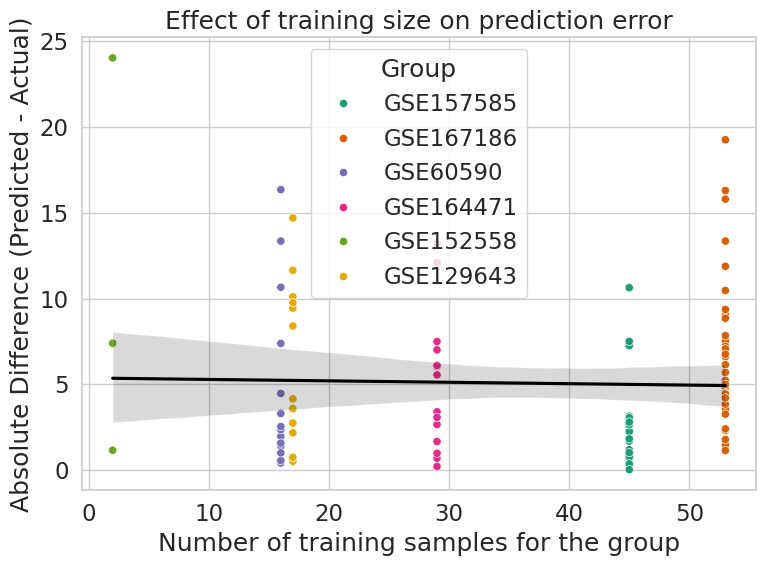

In [262]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=results, x='Train_Group_Count', y='Difference', hue='Group', palette='Dark2')
sns.regplot(data=results, x='Train_Group_Count', y='Difference', scatter=False, color='black')
plt.title('Effect of training size on prediction error')
plt.xlabel('Number of training samples for the group')
plt.ylabel('Absolute Difference (Predicted - Actual)')
plt.tight_layout()
plt.savefig(f"deep_learning/Results/Group_vs_Difference_{model_name}{'_remove_GSE152558' if remove_GSE152558 else ''}.svg", bbox_inches='tight')
plt.show()

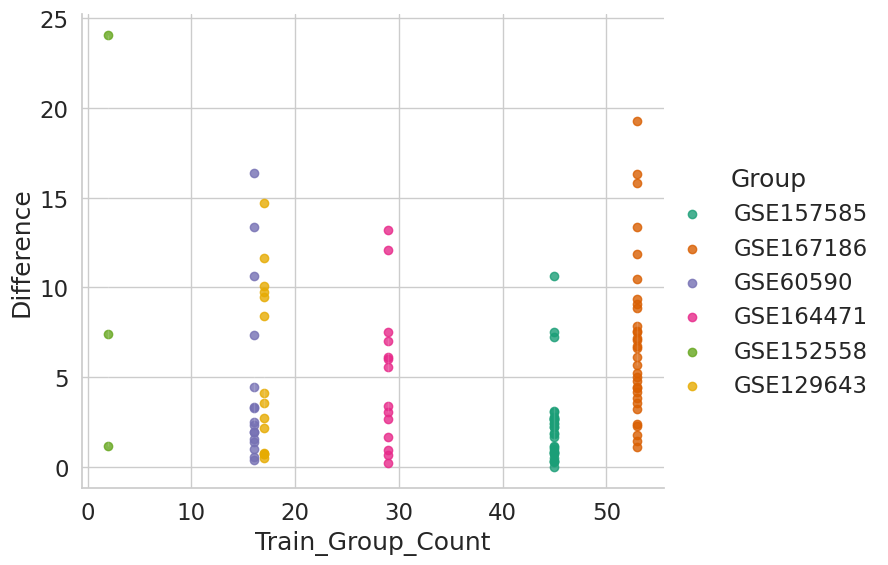

In [263]:
sns.lmplot(
    data=results,
    x='Train_Group_Count',
    y='Difference',
    hue='Group',
    palette='Dark2',
    height=6,
    aspect=1.2,
)

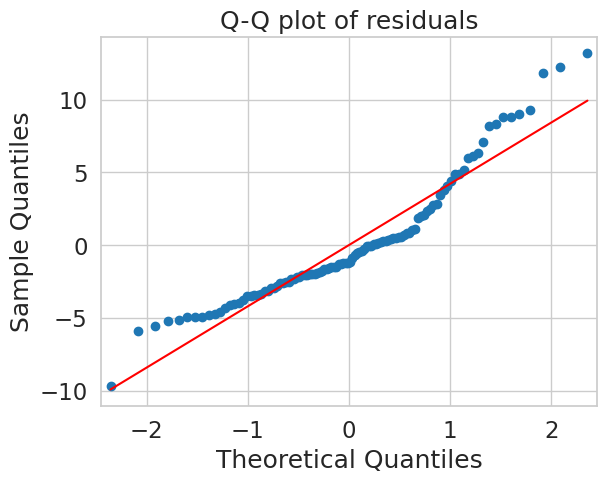

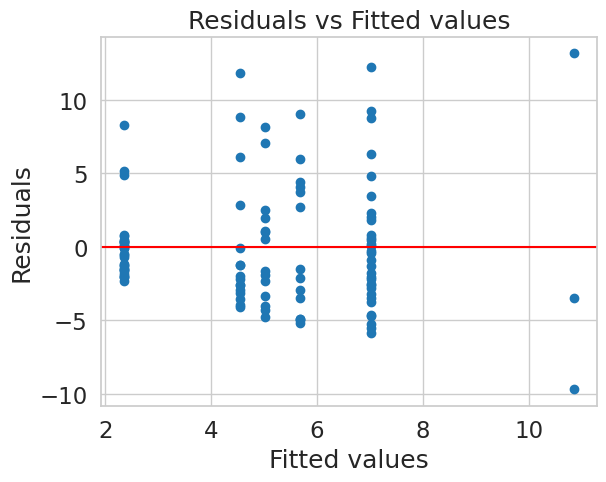

In [264]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

sm.qqplot(model.resid, line='s')
plt.title("Q-Q plot of residuals")
plt.show()

plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted values")
plt.savefig(f"deep_learning/Results/Group_vs_Difference_{model_name}{'_remove_GSE152558' if remove_GSE152558 else ''}_residuals_vs_fitted.svg", bbox_inches='tight')
plt.show()

/tmp/ipykernel_17131/2303311567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(results, x='Difference', y='Group', inner='stick', palette='Dark2')


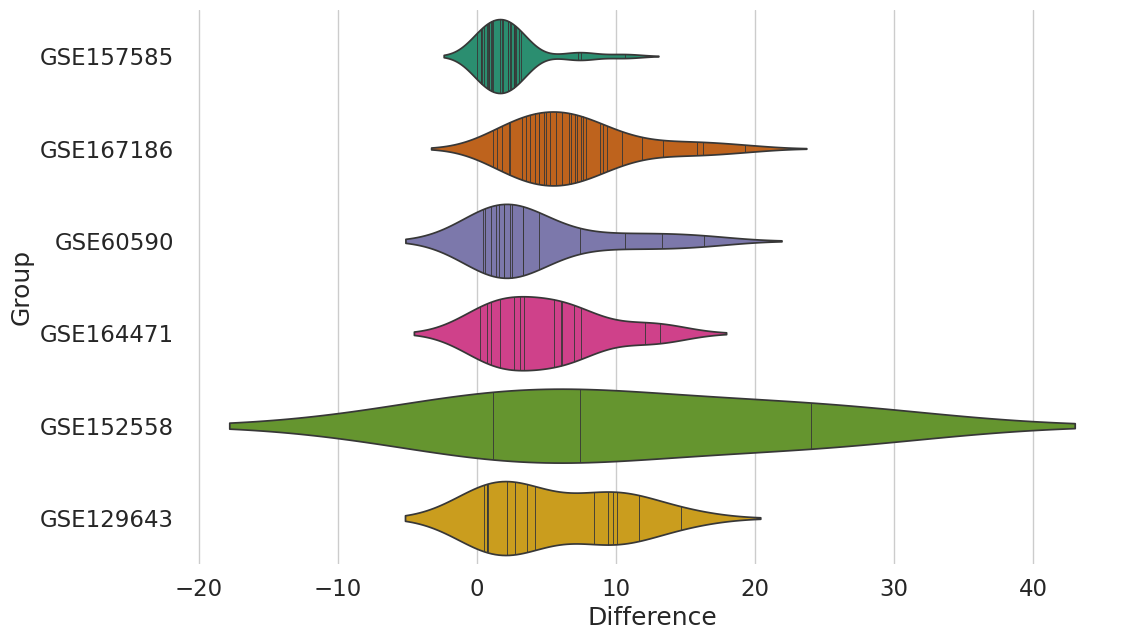

In [265]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results['Group'].unique()))
plt.figure(figsize=figsize)
results['Difference'] = abs(results['Predicted'] - results['Actual'])
sns.violinplot(results, x='Difference', y='Group', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)
#plt.savefig("Group_vs_Difference_Catboost_40_extended.svg", bbox_inches='tight')

# Compute erros

In [272]:
ridge_df

,Actual,Predicted,Group
0,24.0,29.056820,GSE157585
1,18.0,24.422029,GSE167186
2,23.0,20.977246,GSE167186
3,26.4,41.666606,GSE60590
4,71.0,77.621266,GSE157585
...,...,...,...
103,71.0,71.858171,GSE157585
104,23.0,26.527594,GSE167186
105,72.0,49.635809,GSE164471
106,71.0,64.093399,GSE157585


In [284]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ridge_df = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/Ridge/results_validation_untoached_Ridge.csv")
cat_df = pd.read_csv("Shap_values/results_validationSet_actualVspredicted_catboost_10.csv", index_col=0)




# Merge Ridge and CatBoost predictions by index. Rename Predicted columns
ridge_df.rename(columns={'Predicted': 'Predicted_Ridge'}, inplace=True)
cat_df.rename(columns={'Predicted': 'Predicted_Catboost'}, inplace=True)

df = ridge_df[['Group', 'Actual', 'Predicted_Ridge']].merge(
    cat_df[['Predicted_Catboost']], left_index=True, right_index=True
)
df

,Group,Actual,Predicted_Ridge,Predicted_Catboost
0,GSE157585,24.0,29.056820,23.134676
1,GSE167186,18.0,24.422029,25.603508
2,GSE167186,23.0,20.977246,24.474362
3,GSE60590,26.4,41.666606,39.749360
4,GSE157585,71.0,77.621266,68.617051
...,...,...,...,...
103,GSE157585,71.0,71.858171,70.976014
104,GSE167186,23.0,26.527594,25.401901
105,GSE164471,72.0,49.635809,75.074340
106,GSE157585,71.0,64.093399,68.201341


In [286]:
# Compute errors
df['Error_Ridge'] = df['Predicted_Ridge'] - df['Actual']
df['Error_Catboost'] = df['Predicted_Catboost'] - df['Actual']

df['AbsError_Ridge'] = df['Error_Ridge'].abs()
df['AbsError_Catboost'] = df['Error_Catboost'].abs()

In [287]:
df

,Group,Actual,Predicted_Ridge,Predicted_Catboost,Error_Ridge,Error_Catboost,AbsError_Ridge,AbsError_Catboost
0,GSE157585,24.0,29.056820,23.134676,5.056820,-0.865324,5.056820,0.865324
1,GSE167186,18.0,24.422029,25.603508,6.422029,7.603508,6.422029,7.603508
2,GSE167186,23.0,20.977246,24.474362,-2.022754,1.474362,2.022754,1.474362
3,GSE60590,26.4,41.666606,39.749360,15.266606,13.349360,15.266606,13.349360
4,GSE157585,71.0,77.621266,68.617051,6.621266,-2.382949,6.621266,2.382949
...,...,...,...,...,...,...,...,...
103,GSE157585,71.0,71.858171,70.976014,0.858171,-0.023986,0.858171,0.023986
104,GSE167186,23.0,26.527594,25.401901,3.527594,2.401901,3.527594,2.401901
105,GSE164471,72.0,49.635809,75.074340,-22.364191,3.074340,22.364191,3.074340
106,GSE157585,71.0,64.093399,68.201341,-6.906601,-2.798659,6.906601,2.798659


In [300]:
summary = (
    df.groupby('Group')
      .agg(
          MAE_Ridge=('AbsError_Ridge', 'mean'),
          MAE_Catboost=('AbsError_Catboost', 'mean')
      )
      .reset_index()
)

summary['Δ_MAE'] = summary['MAE_Catboost'] - summary['MAE_Ridge']

# Merge training group info (if available)
_training_set = training_set.copy()
_training_set.rename(columns={'Experiment': 'Group'}, inplace=True)
train_counts = (
    _training_set.groupby('Group')
    .size()
    .reset_index(name='Train_Group_Count')
)
summary = summary.merge(train_counts, on='Group', how='left')

summary.sort_values('MAE_Ridge', inplace=True)
summary

,Group,MAE_Ridge,MAE_Catboost,Δ_MAE,Train_Group_Count
2,GSE157585,5.030312,2.341388,-2.688923,45
4,GSE167186,5.678292,7.022827,1.344535,53
5,GSE60590,6.626139,4.536483,-2.089656,16
0,GSE129643,9.879993,5.674266,-4.205727,17
3,GSE164471,10.381234,5.010162,-5.371072,29
1,GSE152558,29.796602,10.862080,-18.934522,2


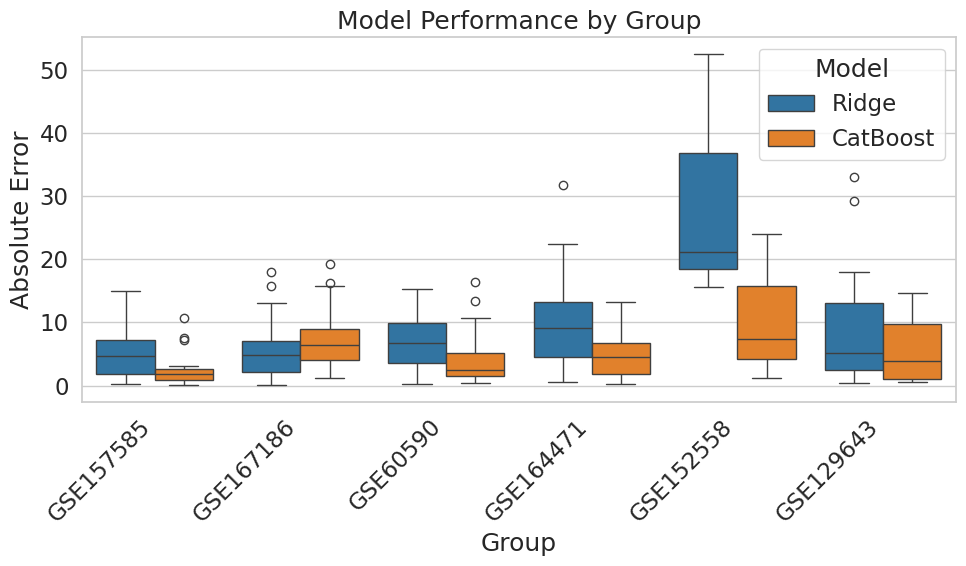

In [296]:
df_long = df.melt(
    id_vars=['Group'],
    value_vars=['AbsError_Ridge', 'AbsError_Catboost'],
    var_name='Model', value_name='Absolute Error'
)

df_long['Model'] = df_long['Model'].replace({
    'AbsError_Ridge': 'Ridge',
    'AbsError_Catboost': 'CatBoost'
})

plt.figure(figsize=(10,6))
sns.boxplot(data=df_long, x='Group', y='Absolute Error', hue='Model')
plt.title("Model Performance by Group")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [301]:
summary

,Group,MAE_Ridge,MAE_Catboost,Δ_MAE,Train_Group_Count
2,GSE157585,5.030312,2.341388,-2.688923,45
4,GSE167186,5.678292,7.022827,1.344535,53
5,GSE60590,6.626139,4.536483,-2.089656,16
0,GSE129643,9.879993,5.674266,-4.205727,17
3,GSE164471,10.381234,5.010162,-5.371072,29
1,GSE152558,29.796602,10.862080,-18.934522,2


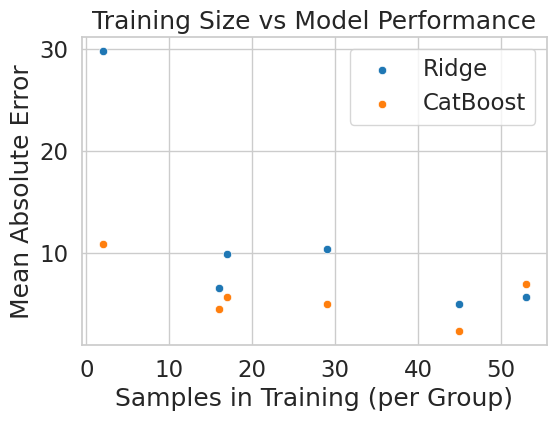

In [302]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=summary, x='Train_Group_Count', y='MAE_Ridge', label='Ridge')
sns.scatterplot(data=summary, x='Train_Group_Count', y='MAE_Catboost', label='CatBoost')
plt.title("Training Size vs Model Performance")
plt.xlabel("Samples in Training (per Group)")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()